In [1]:
print("Hello Guys")

Hello Guys


In [2]:
# !apt-get install tree -qq
# !git clone https://github.com/megvii-research/NAFNet.git
# !tree NAFNet -L 6

In [3]:
# !head -100 NAFNet/basicsr/test.py
# !cat NAFNet/options/test/REDS/NAFNet-width64.yml
# !cat NAFNet/predict.py
# NAFNet-REDS-width64.pth

In [4]:

!pip install -q yapf
!git clone https://github.com/megvii-research/NAFNet.git
%cd NAFNet
!pip install -r requirements.txt

from google.colab import drive
drive.mount('/content/drive')

# ========== 路徑設定 ==========
DATA_DIR = "/content/drive/MyDrive/IP_Final"

INPUT_DIR = f"{DATA_DIR}/test"
OMD_DIR = f"{DATA_DIR}/omd"
NAF_OUTPUT_DIR = f"{DATA_DIR}/naf_results"
OMDNAF_OUTPUT_DIR = f"{DATA_DIR}/omdnaf_results"
COMPARE_DIR = f"{DATA_DIR}/comparison"

import os
os.makedirs(NAF_OUTPUT_DIR, exist_ok=True)
os.makedirs(OMDNAF_OUTPUT_DIR, exist_ok=True)
os.makedirs(COMPARE_DIR, exist_ok=True)

# ========== NAFNet 模型載入 ==========
import torch
import cv2
import numpy as np
from tqdm import tqdm
from glob import glob
from basicsr.utils import img2tensor, tensor2img
from basicsr.models import create_model
from basicsr.utils.options import parse

PTH_PATH = f"{DATA_DIR}/NAFNet-REDS-width64.pth"

opt = parse('options/test/REDS/NAFNet-width64.yml', is_train=False)
opt['dist'] = False
opt['path']['pretrain_network_g'] = PTH_PATH
model = create_model(opt)
model.feed_data(data={'lq': torch.randn(1, 3, 64, 64)})

# ========== TTA 函數（保持不變）==========
MAX_SIZE = 1440
USE_TTA = True  # 保留 TTA

def tta_transform(img, mode):
    if mode == 0:
        return img
    elif mode == 1:
        return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif mode == 2:
        return cv2.rotate(img, cv2.ROTATE_180)
    elif mode == 3:
        return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    elif mode == 4:
        return cv2.flip(img, 1)
    elif mode == 5:
        return cv2.flip(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE), 1)
    elif mode == 6:
        return cv2.flip(cv2.rotate(img, cv2.ROTATE_180), 1)
    elif mode == 7:
        return cv2.flip(cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE), 1)

def tta_inverse(img, mode):
    if mode == 0:
        return img
    elif mode == 1:
        return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    elif mode == 2:
        return cv2.rotate(img, cv2.ROTATE_180)
    elif mode == 3:
        return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif mode == 4:
        return cv2.flip(img, 1)
    elif mode == 5:
        return cv2.rotate(cv2.flip(img, 1), cv2.ROTATE_90_COUNTERCLOCKWISE)
    elif mode == 6:
        return cv2.flip(cv2.rotate(img, cv2.ROTATE_180), 1)
    elif mode == 7:
        return cv2.rotate(cv2.flip(img, 1), cv2.ROTATE_90_CLOCKWISE)

def resize_if_needed(img, max_size=MAX_SIZE):
    h, w = img.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        new_w, new_h = int(w * scale), int(h * scale)
        return cv2.resize(img, (new_w, new_h)), scale
    return img, 1.0

def deblur_with_nafnet(img, use_tta=USE_TTA):
    """
    對輸入圖像進行 NAFNet 去模糊
    img: BGR numpy array
    return: 去模糊後的 BGR numpy array
    """
    original_size = img.shape[:2]
    img_resized, scale = resize_if_needed(img)

    if not use_tta:
        img_tensor = img2tensor(img_resized.astype('float32') / 255.0, bgr2rgb=True, float32=True)
        model.feed_data(data={'lq': img_tensor.unsqueeze(0)})
        model.test()
        result = tensor2img([model.get_current_visuals()['result']], rgb2bgr=True)
    else:
        results = []
        for mode in range(8):
            transformed = tta_transform(img_resized, mode)
            img_tensor = img2tensor(transformed.astype('float32') / 255.0, bgr2rgb=True, float32=True)
            model.feed_data(data={'lq': img_tensor.unsqueeze(0)})
            model.test()
            pred = tensor2img([model.get_current_visuals()['result']], rgb2bgr=True)
            back_transformed = tta_inverse(pred, mode)
            results.append(back_transformed.astype(np.float32))
        result = np.mean(results, axis=0).astype(np.uint8)

    if scale != 1.0:
        result = cv2.resize(result, (original_size[1], original_size[0]))

    return result

# ========== 步驟1：如果 NAFNet 單獨結果不存在，先產生 ==========
print("=" * 60)
print("步驟 1: 產生 NAFNet 單獨結果")
print("=" * 60)

image_paths = glob(f"{INPUT_DIR}/*.jpg") + glob(f"{INPUT_DIR}/*.png") + glob(f"{INPUT_DIR}/*.jpeg")
image_names = [os.path.basename(p) for p in image_paths]

# 檢查哪些圖片還沒有 NAFNet 結果
need_naf = []
for img_path, name in zip(image_paths, image_names):
    out_path = os.path.join(NAF_OUTPUT_DIR, name)
    if not os.path.exists(out_path):
        need_naf.append((img_path, name))

if need_naf:
    for img_path, name in tqdm(need_naf, desc="NAFNet"):
        try:
            img = cv2.imread(img_path)
            result = deblur_with_nafnet(img)
            out_path = os.path.join(NAF_OUTPUT_DIR, name)
            cv2.imwrite(out_path, result)
        except Exception as e:
            print(f"NAFNet 失敗 {img_path}: {e}")
else:
    print("NAFNet 結果已存在，略過")

# ========== 步驟2：OMDNet → NAFNet 串接 ==========
print("\n" + "=" * 60)
print("步驟 2: OMDNet → NAFNet 串接")
print("=" * 60)

# 讀取 OMD 結果作為輸入，再跑一次 NAFNet
omd_paths = [os.path.join(OMD_DIR, name) for name in image_names]

for name, omd_path in tqdm(zip(image_names, omd_paths), desc="OMD+NAF", total=len(image_names)):
    out_path = os.path.join(OMDNAF_OUTPUT_DIR, name)

    # 如果已存在則略過
    if os.path.exists(out_path):
        continue

    try:
        if not os.path.exists(omd_path):
            print(f"OMD 結果不存在: {omd_path}")
            continue

        omd_img = cv2.imread(omd_path)
        result = deblur_with_nafnet(omd_img)
        cv2.imwrite(out_path, result)
    except Exception as e:
        print(f"OMD+NAF 失敗 {name}: {e}")

# ========== 步驟3：讀取所有圖片 ==========
print("\n" + "=" * 60)
print("步驟 3: 載入圖片")
print("=" * 60)

input_imgs = {}
naf_imgs = {}
omd_imgs = {}
omdnaf_imgs = {}

for name in image_names:
    # Input 原始圖片
    input_path = os.path.join(INPUT_DIR, name)
    input_imgs[name] = cv2.imread(input_path)

    # NAFNet 單獨結果
    naf_path = os.path.join(NAF_OUTPUT_DIR, name)
    if os.path.exists(naf_path):
        naf_imgs[name] = cv2.imread(naf_path)
    else:
        print(f"警告: {name} NAFNet 結果不存在")

    # OMD 單獨結果
    omd_path = os.path.join(OMD_DIR, name)
    if os.path.exists(omd_path):
        omd_imgs[name] = cv2.imread(omd_path)
    else:
        print(f"警告: {name} OMD 結果不存在")

    # OMD+NAF 串接結果
    omdnaf_path = os.path.join(OMDNAF_OUTPUT_DIR, name)
    if os.path.exists(omdnaf_path):
        omdnaf_imgs[name] = cv2.imread(omdnaf_path)
    else:
        print(f"警告: {name} OMD+NAF 結果不存在")

# ========== 步驟4：產生比較圖與 Heatmap ==========
print("\n" + "=" * 60)
print("步驟 4: 產生比較圖與 Heatmap")
print("=" * 60)

import matplotlib.pyplot as plt

# 儲存統計資料
stats = []

for name in image_names:
    try:
        input_img = input_imgs[name]
        naf_img = naf_imgs.get(name)
        omd_img = omd_imgs.get(name)
        omdnaf_img = omdnaf_imgs.get(name)

        if naf_img is None or omd_img is None or omdnaf_img is None:
            print(f"跳過 {name}: 缺少必要圖片")
            continue

        # 確保尺寸一致（以 input 為基準）
        h, w = input_img.shape[:2]

        if naf_img.shape[:2] != (h, w):
            naf_img = cv2.resize(naf_img, (w, h))
        if omd_img.shape[:2] != (h, w):
            omd_img = cv2.resize(omd_img, (w, h))
        if omdnaf_img.shape[:2] != (h, w):
            omdnaf_img = cv2.resize(omdnaf_img, (w, h))

        # 計算差異圖（灰階，值域 0-255）
        diff_naf_input = cv2.cvtColor(cv2.absdiff(input_img, naf_img), cv2.COLOR_BGR2GRAY)
        diff_omd_omdnaf = cv2.cvtColor(cv2.absdiff(omd_img, omdnaf_img), cv2.COLOR_BGR2GRAY)
        diff_input_omdnaf = cv2.cvtColor(cv2.absdiff(input_img, omdnaf_img), cv2.COLOR_BGR2GRAY)

        # 計算統計數據
        stats.append({
            'name': name,
            'naf_vs_input_mean': np.mean(diff_naf_input),
            'naf_vs_input_rmse': np.sqrt(np.mean((input_img.astype(float) - naf_img.astype(float))**2)),
            'omd_vs_omdnaf_mean': np.mean(diff_omd_omdnaf),
            'omd_vs_omdnaf_rmse': np.sqrt(np.mean((omd_img.astype(float) - omdnaf_img.astype(float))**2)),
            'omdnaf_vs_input_mean': np.mean(diff_input_omdnaf),
            'omdnaf_vs_input_rmse': np.sqrt(np.mean((input_img.astype(float) - omdnaf_img.astype(float))**2)),
        })

        # 建立 3x3 網格圖
        fig, axes = plt.subplots(3, 3, figsize=(18, 18))

        # 第一行：Input | NAF | diff(NAF, Input)
        axes[0, 0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title('Input', fontsize=12)
        axes[0, 0].axis('off')

        axes[0, 1].imshow(cv2.cvtColor(naf_img, cv2.COLOR_BGR2RGB))
        axes[0, 1].set_title('NAFNet', fontsize=12)
        axes[0, 1].axis('off')

        im00 = axes[0, 2].imshow(diff_naf_input, cmap='hot', vmin=0, vmax=50)
        axes[0, 2].set_title(f'Diff (NAF, Input)\nmean={stats[-1]["naf_vs_input_mean"]:.1f}', fontsize=12)
        axes[0, 2].axis('off')
        plt.colorbar(im00, ax=axes[0, 2], fraction=0.046, pad=0.04)

        # 第二行：OMD | OMD+NAF | diff(OMD, OMD+NAF)
        axes[1, 0].imshow(cv2.cvtColor(omd_img, cv2.COLOR_BGR2RGB))
        axes[1, 0].set_title('OMDNet', fontsize=12)
        axes[1, 0].axis('off')

        axes[1, 1].imshow(cv2.cvtColor(omdnaf_img, cv2.COLOR_BGR2RGB))
        axes[1, 1].set_title('OMDNet → NAFNet', fontsize=12)
        axes[1, 1].axis('off')

        im10 = axes[1, 2].imshow(diff_omd_omdnaf, cmap='hot', vmin=0, vmax=50)
        axes[1, 2].set_title(f'Diff (OMD, OMD+NAF)\nmean={stats[-1]["omd_vs_omdnaf_mean"]:.1f}', fontsize=12)
        axes[1, 2].axis('off')
        plt.colorbar(im10, ax=axes[1, 2], fraction=0.046, pad=0.04)

        # 第三行：Input | OMD+NAF | diff(Input, OMD+NAF)
        axes[2, 0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
        axes[2, 0].set_title('Input', fontsize=12)
        axes[2, 0].axis('off')

        axes[2, 1].imshow(cv2.cvtColor(omdnaf_img, cv2.COLOR_BGR2RGB))
        axes[2, 1].set_title('OMDNet → NAFNet', fontsize=12)
        axes[2, 1].axis('off')

        im20 = axes[2, 2].imshow(diff_input_omdnaf, cmap='hot', vmin=0, vmax=50)
        axes[2, 2].set_title(f'Diff (Input, OMD+NAF)\nmean={stats[-1]["omdnaf_vs_input_mean"]:.1f}', fontsize=12)
        axes[2, 2].axis('off')
        plt.colorbar(im20, ax=axes[2, 2], fraction=0.046, pad=0.04)

        plt.suptitle(f'Comparison: {name}', fontsize=14, fontweight='bold')
        plt.tight_layout()

        # 儲存比較圖
        compare_path = os.path.join(COMPARE_DIR, f"compare_{os.path.splitext(name)[0]}.png")
        plt.savefig(compare_path, dpi=150, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"處理 {name} 時發生錯誤: {e}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 676.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 105.2 kB/s eta 0:00:00
Cloning into 'NAFNet'...
remote: Enumerating objects: 521, done.
remote: Counting objects: 100% (339/339), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 521 (delta 263), reused 223 (delta 223), pack-reused 182 (from 1)
Receiving objects: 100% (521/521), 16.19 MiB | 20.70 MiB/s, done.
Resolving deltas: 100% (279/279), done.
/content/NAFNet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.2 MB/s eta 0:00:00
Mounted at /content/drive
 load net keys <built-in method keys of dict object at 0x79c742579bc0>
步驟 1: 產生 NAFNet 單獨結果


NAFNet: 100%|██████████| 15/15 [04:48<00:00, 19.22s/it]



步驟 2: OMDNet → NAFNet 串接


OMD+NAF: 100%|██████████| 15/15 [02:36<00:00, 10.45s/it]



步驟 3: 載入圖片

步驟 4: 產生比較圖與 Heatmap


In [5]:
# ============================================
# 進階比較圖：四種組合，分別儲存
# ============================================

print("\n" + "=" * 60)
print("步驟 5: 產生四種比較圖（分別儲存）")
print("=" * 60)

import matplotlib.pyplot as plt

# 儲存統計資料（用於後續輸出）
stats = []

for idx, name in enumerate(image_names):
    try:
        input_img = input_imgs[name]
        naf_img = naf_imgs.get(name)
        omd_img = omd_imgs.get(name)
        omdnaf_img = omdnaf_imgs.get(name)

        if naf_img is None or omd_img is None or omdnaf_img is None:
            print(f"跳過 {name}: 缺少必要圖片")
            continue

        # 確保尺寸一致（以 input 為基準）
        h, w = input_img.shape[:2]

        if naf_img.shape[:2] != (h, w):
            naf_img = cv2.resize(naf_img, (w, h))
        if omd_img.shape[:2] != (h, w):
            omd_img = cv2.resize(omd_img, (w, h))
        if omdnaf_img.shape[:2] != (h, w):
            omdnaf_img = cv2.resize(omdnaf_img, (w, h))

        # 計算差異圖
        diff_naf_input = cv2.cvtColor(cv2.absdiff(input_img, naf_img), cv2.COLOR_BGR2GRAY)
        diff_omd_input = cv2.cvtColor(cv2.absdiff(input_img, omd_img), cv2.COLOR_BGR2GRAY)
        diff_omd_omdnaf = cv2.cvtColor(cv2.absdiff(omd_img, omdnaf_img), cv2.COLOR_BGR2GRAY)
        diff_input_omdnaf = cv2.cvtColor(cv2.absdiff(input_img, omdnaf_img), cv2.COLOR_BGR2GRAY)

        # 計算統計數據
        stats.append({
            'name': name,
            'naf_vs_input_mean': np.mean(diff_naf_input),
            'naf_vs_input_rmse': np.sqrt(np.mean((input_img.astype(float) - naf_img.astype(float))**2)),
            'omd_vs_input_mean': np.mean(diff_omd_input),
            'omd_vs_input_rmse': np.sqrt(np.mean((input_img.astype(float) - omd_img.astype(float))**2)),
            'omd_vs_omdnaf_mean': np.mean(diff_omd_omdnaf),
            'omd_vs_omdnaf_rmse': np.sqrt(np.mean((omd_img.astype(float) - omdnaf_img.astype(float))**2)),
            'omdnaf_vs_input_mean': np.mean(diff_input_omdnaf),
            'omdnaf_vs_input_rmse': np.sqrt(np.mean((input_img.astype(float) - omdnaf_img.astype(float))**2)),
        })

        base_name = os.path.splitext(name)[0]

        # ===== 圖1: Input vs NAFNet =====
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Input', fontsize=12)
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(naf_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title('NAFNet', fontsize=12)
        axes[1].axis('off')
        im = axes[2].imshow(diff_naf_input, cmap='hot', vmin=0, vmax=50)
        axes[2].set_title(f'Diff (NAF, Input)\nmean={stats[-1]["naf_vs_input_mean"]:.1f}', fontsize=12)
        axes[2].axis('off')
        plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
        plt.suptitle(f'Comparison: {name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(COMPARE_DIR, f"1_naf_vs_input_{base_name}.png"), dpi=150, bbox_inches='tight')
        plt.close()

        # ===== 圖2: Input vs OMDNet =====
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Input', fontsize=12)
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(omd_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title('OMDNet', fontsize=12)
        axes[1].axis('off')
        im = axes[2].imshow(diff_omd_input, cmap='hot', vmin=0, vmax=50)
        axes[2].set_title(f'Diff (OMD, Input)\nmean={stats[-1]["omd_vs_input_mean"]:.1f}', fontsize=12)
        axes[2].axis('off')
        plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
        plt.suptitle(f'Comparison: {name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(COMPARE_DIR, f"2_omd_vs_input_{base_name}.png"), dpi=150, bbox_inches='tight')
        plt.close()

        # ===== 圖3: OMD vs OMD+NAF =====
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(cv2.cvtColor(omd_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title('OMDNet', fontsize=12)
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(omdnaf_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title('OMDNet → NAFNet', fontsize=12)
        axes[1].axis('off')
        im = axes[2].imshow(diff_omd_omdnaf, cmap='hot', vmin=0, vmax=50)
        axes[2].set_title(f'Diff (OMD, OMD+NAF)\nmean={stats[-1]["omd_vs_omdnaf_mean"]:.1f}', fontsize=12)
        axes[2].axis('off')
        plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
        plt.suptitle(f'Comparison: {name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(COMPARE_DIR, f"3_omd_vs_omdnaf_{base_name}.png"), dpi=150, bbox_inches='tight')
        plt.close()

        # ===== 圖4: Input vs OMD+NAF =====
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Input', fontsize=12)
        axes[0].axis('off')
        axes[1].imshow(cv2.cvtColor(omdnaf_img, cv2.COLOR_BGR2RGB))
        axes[1].set_title('OMDNet → NAFNet', fontsize=12)
        axes[1].axis('off')
        im = axes[2].imshow(diff_input_omdnaf, cmap='hot', vmin=0, vmax=50)
        axes[2].set_title(f'Diff (Input, OMD+NAF)\nmean={stats[-1]["omdnaf_vs_input_mean"]:.1f}', fontsize=12)
        axes[2].axis('off')
        plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
        plt.suptitle(f'Comparison: {name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(COMPARE_DIR, f"4_input_vs_omdnaf_{base_name}.png"), dpi=150, bbox_inches='tight')
        plt.close()

        print(f"已完成 {idx+1}/{len(image_names)}: {name}")

    except Exception as e:
        print(f"處理 {name} 時發生錯誤: {e}")

# ============================================
# 輸出統計摘要
# ============================================
print("\n" + "=" * 60)
print("統計摘要 (Diff Mean / RMSE)")
print("=" * 60)

if stats:
    print(f"\n{'圖片名稱':<45} {'NAF vs Input':>20} {'OMD vs Input':>20} {'OMD+NAF vs Input':>20}")
    print("-" * 105)

    for s in stats:
        name_short = s['name'][:43]
        naf_str = f"{s['naf_vs_input_mean']:.2f} / {s['naf_vs_input_rmse']:.2f}"
        omd_str = f"{s['omd_vs_input_mean']:.2f} / {s['omd_vs_input_rmse']:.2f}"
        omdnaf_str = f"{s['omdnaf_vs_input_mean']:.2f} / {s['omdnaf_vs_input_rmse']:.2f}"
        print(f"{name_short:<45} {naf_str:>20} {omd_str:>20} {omdnaf_str:>20}")

    print("-" * 105)

    # 計算平均
    avg_naf_mean = np.mean([s['naf_vs_input_mean'] for s in stats])
    avg_naf_rmse = np.mean([s['naf_vs_input_rmse'] for s in stats])
    avg_omd_mean = np.mean([s['omd_vs_input_mean'] for s in stats])
    avg_omd_rmse = np.mean([s['omd_vs_input_rmse'] for s in stats])
    avg_omdnaf_mean = np.mean([s['omdnaf_vs_input_mean'] for s in stats])
    avg_omdnaf_rmse = np.mean([s['omdnaf_vs_input_rmse'] for s in stats])

    print(f"\n{'全體平均':<45} {f'{avg_naf_mean:.2f} / {avg_naf_rmse:.2f}':>20} {f'{avg_omd_mean:.2f} / {avg_omd_rmse:.2f}':>20} {f'{avg_omdnaf_mean:.2f} / {avg_omdnaf_rmse:.2f}':>20}")
    print("=" * 105)

    # 改善分析
    print(f"\n改善分析:")
    print(f"  NAFNet 單獨 RMSE 平均: {avg_naf_rmse:.2f}")
    print(f"  OMDNet 單獨 RMSE 平均: {avg_omd_rmse:.2f}")
    print(f"  OMD+NAF 串接 RMSE 平均: {avg_omdnaf_rmse:.2f}")

    improvement_naf = (avg_naf_rmse - avg_omdnaf_rmse) / avg_naf_rmse * 100
    improvement_omd = (avg_omd_rmse - avg_omdnaf_rmse) / avg_omd_rmse * 100

    print(f"  OMD+NAF 相比 NAFNet 改善: {improvement_naf:+.1f}%")
    print(f"  OMD+NAF 相比 OMDNet 改善: {improvement_omd:+.1f}%")

else:
    print("無統計數據可輸出")

print(f"\n比較圖已儲存至: {COMPARE_DIR}")
print("完成！")


步驟 5: 產生四種比較圖（分別儲存）
已完成 1/15: 05_Red_Taxi_Through_City_Lights.jpg
已完成 2/15: 09_White_Truck_Zoom_Blur_Rain.jpg
已完成 3/15: 08_KFC_Rider_Rainy_Night_Delivery.jpg
已完成 4/15: 04_Cyclist_Passing_Warm_Storefront_Lights.jpg
已完成 5/15: 02_Red_Sign_Reflections_Blurred_Glass.jpg
已完成 6/15: 14_Yellow_Chair_Alley_Motion_Portrait.jpg
已完成 7/15: 03_Dim_Night_Market_Food_Alley.jpg
已完成 8/15: 11_Fumachi_Night_Market_Ghost_Crowd.jpg
已完成 9/15: 06_Shaking_Neon_Signs_Overhead_Night.jpg
已完成 10/15: 01_Urban_Light_Trails_Walking_Figure.jpg
已完成 11/15: 12_Sidewalk_Signage_In_City_Lights.jpg
已完成 12/15: 07_Yellow_Taxi_Neon_Rain_Street.jpg
已完成 13/15: 10_Crowded_Night_Market_Face_Glow.jpg
已完成 14/15: 15_Photographer_Reflected_In_Night_Glass.jpg
已完成 15/15: 13_FamilyMart_Window_Reflections_Night_Traffic.jpg

統計摘要 (Diff Mean / RMSE)

圖片名稱                                                  NAF vs Input         OMD vs Input     OMD+NAF vs Input
------------------------------------------------------------------------------------

處理圖片: 09_White_Truck_Zoom_Blur_Rain.jpg
  原始尺寸: 1024 x 688
  執行 NAFNet 去模糊 (TTA=ON)...
  結果儲存至: /content/drive/MyDrive/IP_Final/single_naf_result/09_White_Truck_Zoom_Blur_Rain.jpg


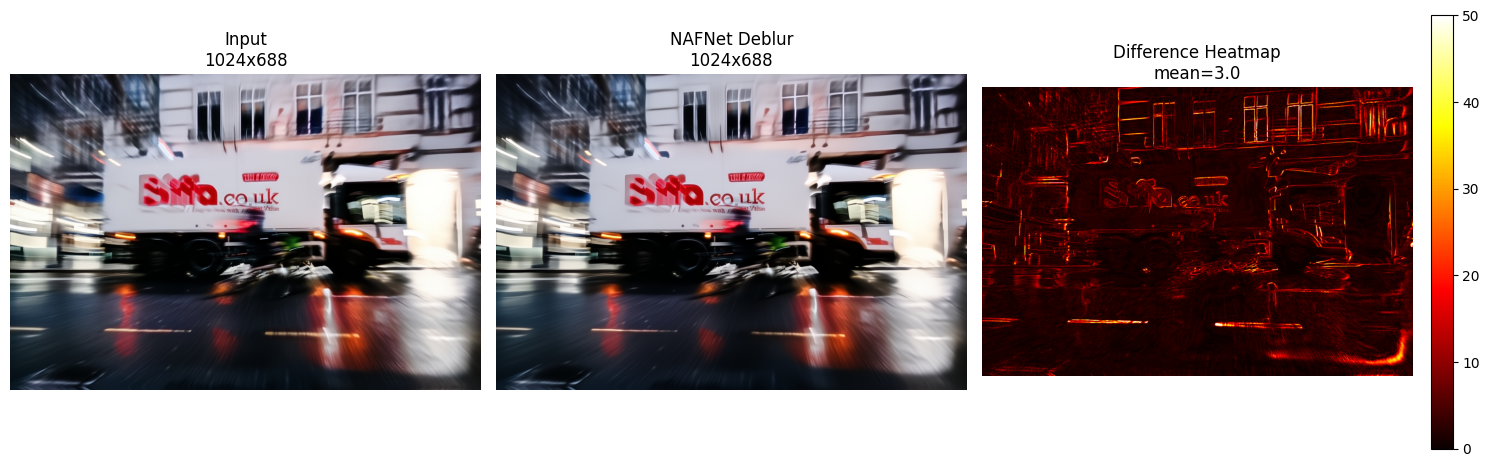

對比圖儲存至: /content/drive/MyDrive/IP_Final/single_naf_result/compare_09_White_Truck_Zoom_Blur_Rain.png

  差異統計:
    Diff Mean: 3.05
    RMSE: 5.63

指定圖片處理完成！


In [6]:
# ============================================
# 指定一張圖片進行 NAFNet 去模糊
# ============================================


# ===== 設定區（請修改這裡）=====
TARGET_IMAGE_NAME = "09_White_Truck_Zoom_Blur_Rain.jpg"  # 替換成你要處理的圖片名稱
SINGLE_OUTPUT_DIR = f"{DATA_DIR}/single_naf_result"  # 輸出資料夾
# ================================

os.makedirs(SINGLE_OUTPUT_DIR, exist_ok=True)

target_path = os.path.join(OMDNAF_OUTPUT_DIR, TARGET_IMAGE_NAME)

if not os.path.exists(target_path):
    print(f"錯誤：找不到圖片 {target_path}")
    print(f"可用的圖片：")
    for name in image_names:
        print(f"  - {name}")
else:
    print(f"處理圖片: {TARGET_IMAGE_NAME}")

    # 讀取並去模糊
    img = cv2.imread(target_path)
    original_size = img.shape[:2]

    print(f"  原始尺寸: {original_size[1]} x {original_size[0]}")
    print("  執行 NAFNet 去模糊 (TTA=ON)...")

    result = deblur_with_nafnet(img, use_tta=USE_TTA)

    # 儲存結果
    output_path = os.path.join(SINGLE_OUTPUT_DIR, TARGET_IMAGE_NAME)
    cv2.imwrite(output_path, result)
    print(f"  結果儲存至: {output_path}")

    # 顯示對比圖
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 原始圖片
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Input\n{original_size[1]}x{original_size[0]}')
    axes[0].axis('off')

    # NAFNet 結果
    axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'NAFNet Deblur\n{result.shape[1]}x{result.shape[0]}')
    axes[1].axis('off')

    # 差異熱圖
    diff = cv2.cvtColor(cv2.absdiff(img, result), cv2.COLOR_BGR2GRAY)
    diff_mean = np.mean(diff)
    im = axes[2].imshow(diff, cmap='hot', vmin=0, vmax=50)
    axes[2].set_title(f'Difference Heatmap\nmean={diff_mean:.1f}')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()

    # 儲存對比圖
    compare_path = os.path.join(SINGLE_OUTPUT_DIR, f"compare_{os.path.splitext(TARGET_IMAGE_NAME)[0]}.png")
    plt.savefig(compare_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"對比圖儲存至: {compare_path}")

    # 計算簡單指標
    mse = np.mean((img.astype(float) - result.astype(float)) ** 2)
    rmse = np.sqrt(mse)
    print(f"\n  差異統計:")
    print(f"    Diff Mean: {diff_mean:.2f}")
    print(f"    RMSE: {rmse:.2f}")

print("\n指定圖片處理完成！")